Mainly adopted from [https://github.com/alanjeffares/discreteVAE](https://github.com/alanjeffares/discreteVAE)

## 1. Needed  packages

In [1]:
import math

import torch
from torch import nn
from torch.nn import functional as F

from torch.distributions import OneHotCategorical
from torchvision import datasets, transforms

from torchinfo import summary

import matplotlib.pyplot as plt

## 2. Discrete VAE model

In [2]:
class VAE(nn.Module):
    def __init__(self, nlat=4, ncat=8):
        super(VAE, self).__init__()
        self.nlat = nlat
        self.ncat = ncat
        self.fc1 = nn.Linear(784, 512)
        self.fc2 = nn.Linear(512, 256)
        self.fc3 = nn.Linear(256, nlat*ncat)
        self.fc4 = nn.Linear(nlat*ncat, 256)
        self.fc5 = nn.Linear(256, 512)
        self.fc6 = nn.Linear(512, 784)

    def encode(self, x):
        h1 = F.relu(self.fc1(x))
        h2 = F.relu(self.fc2(h1))
        logits = self.fc3(h2).view(len(x), self.nlat, self.ncat)
        return F.softmax(logits, -1)
    
    def decode(self, z):
        h4 = F.relu(self.fc4(z.view(len(z), self.nlat*self.ncat)))
        h5 = F.relu(self.fc5(h4))
        return F.sigmoid(self.fc6(h5))
    
    def sample(self, p):
        m = OneHotCategorical(p)
        return m.sample()
        
    def forward(self, x):
        """
        x: (B, 784) flattened MNIST in [0,1]
        returns:
          x_hat: (B, 784)
        """
        z = self.encode(x)
        x_hat = self.decode(z)
        return x_hat

## 3. Get device and initialize model

In [3]:
def get_device():
    if torch.cuda.is_available():
        return torch.device("cuda")
    if hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
        try:
            _ = torch.zeros(1, device="mps")
            return torch.device("mps")
        except Exception:
            pass
    return torch.device("cpu")

DEVICE = get_device()
print("Using device:", DEVICE)

Using device: cuda


In [4]:
batch_size  = 128
per_img_size = 784
epochs = 160
nlat = 4
ncat = 8
device = get_device()
discrete_vae = VAE(nlat, ncat).to(device)
summary(discrete_vae, input_size=(batch_size, per_img_size), device=str(device))

Layer (type:depth-idx)                   Output Shape              Param #
VAE                                      [128, 784]                --
├─Linear: 1-1                            [128, 512]                401,920
├─Linear: 1-2                            [128, 256]                131,328
├─Linear: 1-3                            [128, 32]                 8,224
├─Linear: 1-4                            [128, 256]                8,448
├─Linear: 1-5                            [128, 512]                131,584
├─Linear: 1-6                            [128, 784]                402,192
Total params: 1,083,696
Trainable params: 1,083,696
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 138.71
Input size (MB): 0.40
Forward/backward pass size (MB): 2.41
Params size (MB): 4.33
Estimated Total Size (MB): 7.14

## 4. Load MNIST dataset

In [5]:
def get_dataloaders(device, batch_size):
    kwargs = {'num_workers': 4, 'pin_memory': True} if device else {}
    train_loader = torch.utils.data.DataLoader(
        datasets.MNIST('./.cache', train=True, download=True,
                    transform=transforms.ToTensor()),
                    batch_size=batch_size, shuffle=True, **kwargs)
    test_loader = torch.utils.data.DataLoader(
        datasets.MNIST('./.cache', train=False, transform=transforms.ToTensor()),
        batch_size=batch_size, shuffle=False, **kwargs)
    return train_loader, test_loader
    
train_loader, test_loader = get_dataloaders(device, batch_size)

## 5. Train and test discrete VAE model

In [6]:
optimizer = torch.optim.Adam(discrete_vae.parameters(), lr=1e-4, maximize=True)
train_elbo_ls = []
test_elbo_ls = []

for epoch in range(1, epochs + 1):
    discrete_vae.train()
    elbo_train = 0
    for x_input, _ in train_loader:
        x_input = x_input.to(device).view(-1, 784)
        x_input = torch.bernoulli(x_input)  # sample a binarized input from the input probabilities
        optimizer.zero_grad()
        p = discrete_vae.encode(x_input)
        z = discrete_vae.sample(p)
        x_recon = discrete_vae.decode(z)
        
        # to calculate gradients (eqns 84, 85) we will need to assemble the respective expressions
        # and then allow pytorch autograd to get the gradients for us using .backward()
        
        # start with the decoder parameters, theta, which only need BCE
        binary_ce = F.binary_cross_entropy(x_recon, x_input, reduction='none').sum(-1)
        loss_decoder = - binary_ce.sum()  # eqn 85 of https://arxiv.org/pdf/2505.10344
        
        # for the encoder we need two things, the entropy and the expectation terms
        entropy = torch.distributions.Categorical(p).entropy().sum()  # eqn 70
        p_sampled = torch.masked_select(p, z == 1.).reshape(p.shape[0], -1)  # probabilites corresponding to sampled z
        B = 125  # this is a baseline, which simply reduces the variance of the gradient estimator without changing the expected value
        expectation = torch.sum((binary_ce - B).detach() * torch.log(p_sampled).sum(-1))  # eqn 81
        loss_encoder = entropy - expectation  # eqn 84
        # put the loss together for backpropogation
        loss = loss_encoder + loss_decoder
        
        # also calculate the ELBO to track performance (eqn 86)
        elbo = entropy - discrete_vae.nlat * math.log(discrete_vae.ncat) - binary_ce.sum()
                
        loss.backward()
        elbo_train += elbo.item()
        optimizer.step()
        
    train_elbo_i = elbo_train / len(train_loader.dataset)

    with torch.no_grad():
        discrete_vae.eval()
        running_kl = 0
        for x_input, _ in test_loader:
            x_input = x_input.to(device).view(-1, 784)
            x_input = torch.bernoulli(x_input)
            p = discrete_vae.encode(x_input)
            z = discrete_vae.sample(p)
            x_recon = discrete_vae.decode(z)
            binary_ce = F.binary_cross_entropy(x_recon, x_input, reduction='none').sum()
            entropy = torch.distributions.Categorical(p).entropy().sum() 
            kl = entropy - discrete_vae.nlat * math.log(discrete_vae.ncat) - binary_ce
            running_kl += kl.item()
        test_elbo_i = running_kl / len(test_loader.dataset)

    print(f'epoch {epoch}: average training loss: {train_elbo_i:.4f}, average testing loss: {test_elbo_i:.4f}')
    
    train_elbo_ls.append(train_elbo_i)
    test_elbo_ls.append(test_elbo_i)
    
torch.save(discrete_vae.state_dict(), 'vae.pt')

epoch 1: average training loss: -245.9581, average testing loss: -198.2272
epoch 2: average training loss: -198.1710, average testing loss: -197.9054
epoch 3: average training loss: -198.0454, average testing loss: -197.8613
epoch 4: average training loss: -197.8544, average testing loss: -197.3676
epoch 5: average training loss: -196.2222, average testing loss: -192.9350
epoch 6: average training loss: -189.4492, average testing loss: -187.6703
epoch 7: average training loss: -187.5956, average testing loss: -186.1610
epoch 8: average training loss: -186.3066, average testing loss: -185.0503
epoch 9: average training loss: -184.9040, average testing loss: -184.1570
epoch 10: average training loss: -183.8654, average testing loss: -182.4481
epoch 11: average training loss: -181.9044, average testing loss: -180.3364
epoch 12: average training loss: -180.1761, average testing loss: -178.6653
epoch 13: average training loss: -177.6881, average testing loss: -175.9619
epoch 14: average tra

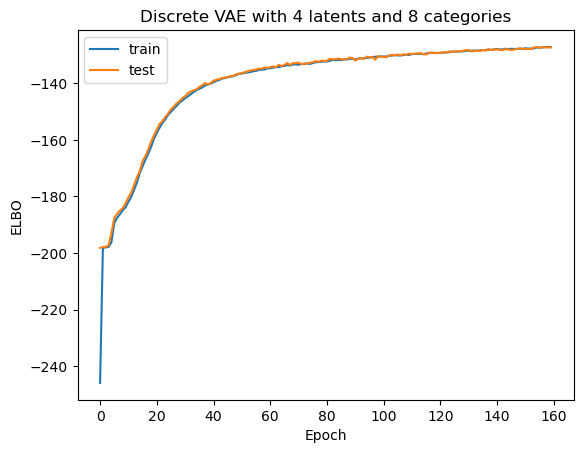

In [7]:
plt.plot(train_elbo_ls, label='train')
plt.plot(test_elbo_ls, label='test')
plt.xlabel('Epoch')
plt.ylabel('ELBO')
plt.legend()
plt.title('Discrete VAE with 4 latents and 8 categories')
plt.show()

## 6. Show generated samples

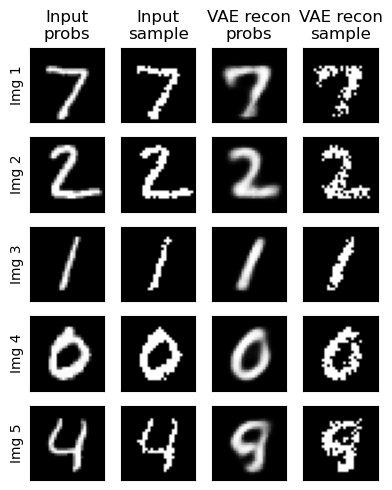

In [17]:
# load the trained model with weights
discrete_vae = VAE(ncat=4, nlat=8)
state_dict = torch.load("vae.pt", map_location="cpu", weights_only=True)
discrete_vae.load_state_dict(state_dict)

# visualize some of the reconstructions
_, test_loader = get_dataloaders(False, 5)
fig, ax = plt.subplots(5, 4, figsize=(4, 5)) 
x_input_probs, _ = next(iter(test_loader))
x_input_binarized = torch.bernoulli(x_input_probs)
x_input = x_input_binarized.view(-1, 784)
p = discrete_vae.encode(x_input)
z = discrete_vae.sample(p)
x_recon_probs = discrete_vae.decode(z)
x_recon_binarized = torch.bernoulli(x_recon_probs)
for i in range(4):
    for j in range(5):
        if i == 0:
            ax[j,i].imshow(x_input_probs[j].view(28, 28).detach().numpy(), cmap='gray')
        elif i == 1:
            ax[j,i].imshow(x_input_binarized[j].view(28, 28).detach().numpy(), cmap='gray')
        elif i == 2:
            ax[j,i].imshow(x_recon_probs[j].view(28, 28).detach().numpy(), cmap='gray')
        else:
            ax[j,i].imshow(x_recon_binarized[j].view(28, 28).detach().numpy(), cmap='gray')
        ax[j, i].set_xticks([])
        ax[j, i].set_yticks([]) 
# add column labels
ax[0, 0].set_title('Input\nprobs')
ax[0, 1].set_title('Input\nsample')
ax[0, 2].set_title('VAE recon\nprobs')
ax[0, 3].set_title('VAE recon\nsample')
# add row labels
for i in range(5):
    ax[i, 0].set_ylabel(f'Img {i+1}')     
plt.tight_layout()
plt.show()

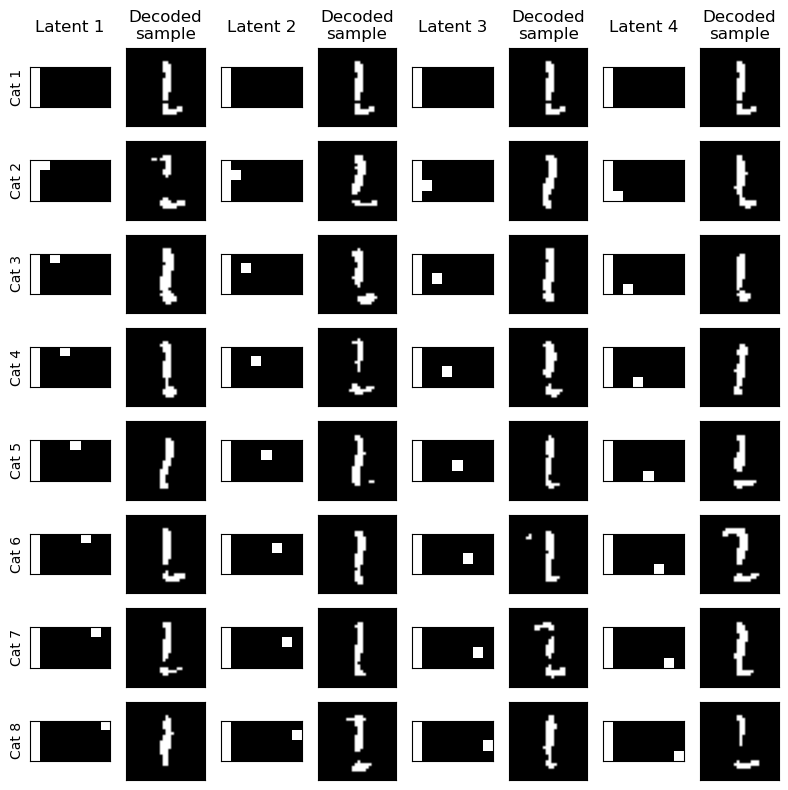

In [18]:
# visualize some of the latent space by fixing values and varying one latent at a time 
fig, ax = plt.subplots(8, 2*4, figsize=(2*4, 8))
for lat in range(4):
    for cat in range(8):
        z = torch.zeros(1, 4, 8)
        z[0, :, 0] = 1
        z[0, lat, 0] = 1
        z[0, lat, cat] = 1
        x_recon = discrete_vae.decode(z)
        x_recon = torch.round(x_recon.view(28, 28)).detach().numpy()

        ax[cat, int(2*lat)].imshow(z.view(4, 8).detach().numpy(), cmap='gray')
        ax[cat, int(2*lat)].set_xticks([])
        ax[cat, int(2*lat)].set_yticks([])
        
        ax[cat, int(2*lat+1)].imshow(x_recon, cmap='gray')
        ax[cat, int(2*lat+1)].set_xticks([])
        ax[cat, int(2*lat+1)].set_yticks([])   
        
        
# add column labels
for i in range(4):# adjust vertical alignment manually
    ax[0, int(2*i)].set_title(f'Latent {i+1}', pad=25)
    ax[0, int(2*i+1)].set_title(f'Decoded\nsample')
# add row labels
for i in range(8):
    ax[i, 0].set_ylabel(f'Cat {i+1}')
plt.tight_layout()
plt.show()